# 子图流式运行
- 在调用父图`invoke`传入`subgraphs=True`即可，子图和父图的流式消息会写入同一个通道
- 开启子图流式运行后，返回的chunk是一个元组(ns, mode, data)
    - ns: 子图的命名空间,如果子图持久化策略为Per-Invocation,则格式为{所在父图节点名称}:{所在父图任务id}, 如果是Per-thread,则只有{所在父图节点名称}；如果是父图流式数据，是空元组
    - mode: stream_mode
    - data: 流式数据, key为父节点名称，value为节点返回状态字典的一个字典

## 分析子图流式调用和chunk结构分析

(('call_subgraph:2554971d-59a2-d8df-ef93-a7daf91cca85',), 'updates', {'subgraph_strip_node': {'stripped_text': 'LangGraph 真有意思'}})
(('call_subgraph:2554971d-59a2-d8df-ef93-a7daf91cca85',), 'updates', {'subgraph_punctuate_node': {'punctuated_text': 'LangGraph 真有意思。'}})
((), 'updates', {'call_subgraph': {'cleaned_text': 'LangGraph 真有意思。'}})


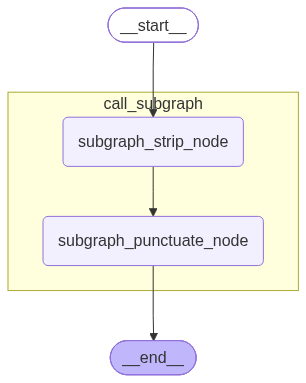

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 构建子图
class SubgraphState(TypedDict):
    raw_text: str # 未清洗文本
    stripped_text: str # 去除收尾空格的文本
    punctuated_text: str # 句尾添加句号的文本

def subgraph_strip_node(state: SubgraphState) -> SubgraphState:
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()

    return {
        "stripped_text": stripped_text
    }

def subgraph_punctuate_node(state: SubgraphState) -> SubgraphState:
    stripped_text = state["stripped_text"]
    punctuated_text = stripped_text + "。"

    return {
        "punctuated_text": punctuated_text
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuate_node", subgraph_punctuate_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuate_node")
builder.add_edge("subgraph_punctuate_node", END)

subgraph = builder.compile()
# subgraph = builder.compile(checkpointer=True)

# 构建父图
class ParentState(TypedDict):
    input_text: str # 输入的未清洗的文本
    cleaned_text: str # 清洗后的文本
    cleaned_text1: str # 清洗后的文本

def call_subgraph(state: ParentState) -> ParentState:
    input_text = state["input_text"]

    res = subgraph.invoke({"raw_text": input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text": cleaned_text
    }

def call_subgraph1(state: ParentState) -> ParentState:
    input_text = state["input_text"]

    res = subgraph.invoke({"raw_text": input_text})
    cleaned_text = res["punctuated_text"]
    return {
        "cleaned_text1": cleaned_text
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
# builder.add_node("call_subgraph1", call_subgraph)

builder.add_edge(START, "call_subgraph")
# builder.add_edge("call_subgraph", "call_subgraph1")
# builder.add_edge("call_subgraph1", END)
builder.add_edge("call_subgraph", END)

parent_graph = builder.compile()

input_text = "   LangGraph 真有意思        "
for chunk in parent_graph.stream(
    {"input_text": input_text},
    subgraphs=True,
    stream_mode=["updates"]
):
    print(chunk)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)


## 多轮对话流式处理


 ============================== -> 第一次运行结果 <- ==============================
“花儿为什么这样红？”这是一个非常经典且富有诗意的问题。它既是一首脍炙人口的老歌歌词，也是一个有趣的自然科学问题。

我们可以从**科学原理**和**文化意境**两个角度来回答你：

### 🌸 从科学角度：色素与进化

花儿之所以呈现红色，主要是由以下因素共同作用的结果：

1.  **花青素（Anthocyanins）**：
    这是最主要的原因。花瓣细胞中含有大量的花青素，这是一种水溶性色素。当细胞液呈**酸性**时，花青素就会显现出**红色**。酸度越高，颜色越红；如果偏碱性，则可能变成蓝色或紫色。

2.  **类胡萝卜素（Carotenoids）**：
    有些红花（如某些郁金香或万寿菊）的颜色也来自类胡萝卜素，它们通常呈现黄色、橙色或红色。

3.  **进化的选择（吸引传粉者）**：
    在自然界中，红色是非常醒目的颜色。许多传粉昆虫（如蜜蜂）和鸟类（如蜂鸟）对红色非常敏感。花朵演化出鲜艳的红色，是为了在绿叶丛中脱颖而出，吸引这些“媒人”来帮助它们传播花粉，从而繁衍后代。

4.  **环境因素**：
    光照、温度和土壤酸碱度也会影响红色的深浅。比如，昼夜温差大、光照充足时，花青素合成更多，花色往往更鲜艳。

---

### 🎶 从文化与情感角度：象征与记忆

如果你是因为那首著名的电影《冰山上的来客》插曲而问起，那么“花儿为什么这样红”象征着：

*   **纯洁的友谊与爱情**：歌词中唱道：“红得好像燃烧的火，它象征着纯洁的友谊和爱情。”
*   **青春的活力与热情**：红色代表生命力、热情和希望。
*   **怀旧与经典**：这句歌词承载了几代人的集体记忆，代表着一种质朴而深沉的情感表达。

---

所以，花儿这样红，既是**大自然精妙的化学杰作**，也是**生命力的热烈绽放**，更可能是你心中某段**美好记忆的触发点**。🌹

你是想到了某个人，还是单纯对自然现象好奇呢？
 ============================== -> 第二次运行结果 <- ==============================
刚才我们聊的话题是：**“花儿为什么这样红

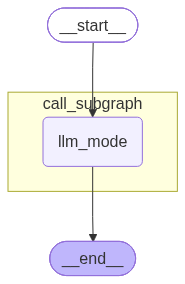

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek

from common import init_simple_dashscope_model

model = init_simple_dashscope_model(
    extra_body={
        "enable_thinking": False
    }
)

# 构建子图
class SubgraphState(MessagesState):
    system_prompt: SystemMessage

def llm_mode(state: SubgraphState) -> SubgraphState:
    system_prompt = state["system_prompt"]
    messages = state["messages"]

    response = model.invoke([system_prompt] + messages)
    return {
        "messages": [response]
    }

builder = StateGraph(state_schema=SubgraphState)
builder.add_node("llm_mode", llm_mode)
builder.add_edge(START, "llm_mode")
builder.add_edge("llm_mode", END)

subgraph = builder.compile(checkpointer=True)

# 构建父图
class ParentState(TypedDict):
    user_input: str
    assistant_response: str

def call_subgraph(state: ParentState) -> ParentState:
    user_input = state["user_input"]

    response = subgraph.invoke(
        {
            "system_prompt": SystemMessage("你是个善解人意的助手"),
            "messages": [HumanMessage(user_input)]
        }
    )

    assistant_response = response["messages"][-1].content

    return {
        "assistant_response": assistant_response
    }

builder = StateGraph(state_schema=ParentState)
builder.add_node("call_subgraph", call_subgraph)
builder.add_edge(START, "call_subgraph")
builder.add_edge("call_subgraph", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "subgraph_stream_test"}}

print("\n", "=" * 30, "-> 第一次运行结果 <-", "=" * 30)
# chunk 形如
# (('call_subgraph',), 'messages', (AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--019efd65-c54e-7012-912e-29ff4f84328e', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'thread_id': 'subgraph_stream_test', 'langgraph_step': 1, 'langgraph_node': 'llm_mode', 'langgraph_triggers': ('branch:to:llm_mode',), 'langgraph_path': ('__pregel_pull', 'llm_mode'), 'langgraph_checkpoint_ns': 'call_subgraph|llm_mode:55577c3e-22da-877a-c77b-f16bdbcd2c6c', 'checkpoint_ns': 'call_subgraph:9c469391-f094-1c1b-c5d7-6578f1603151', 'ls_provider': 'deepseek', 'ls_model_name': 'deepseek-v4-flash', 'ls_model_type': 'chat', 'ls_temperature': None}))
for chunk in parent_graph.stream(
    {
        "user_input": "花儿为什么这样红？"
    },
    config=config,
    subgraphs=True,
    stream_mode=["messages"]
):
    print(chunk[2][0].content, end="", flush=True)

print("\n", "=" * 30, "-> 第二次运行结果 <-", "=" * 30)
for chunk in parent_graph.stream(
    {
        "user_input": "刚才我们聊了什么？"
    },
    config=config,
    subgraphs=True,
    stream_mode=["messages"]
):
    print(chunk[2][0].content, end="", flush=True)

from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)